# **DATA INFORMATION QUALITY PROJECT**
----

**Stefan Calugaru**  
Personal Code: 10852010 – Student ID: 212886  

**Stefano Molteni**  
Personal Code: 10894104 – Student ID: 306650  

**Gabriele Pedesini**  
Personal Code: 10840961 – Student ID: 304425

In [1]:
# import necessary libraries
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import linear_model
from sklearn.preprocessing import OneHotEncoder
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules
from mlxtend.frequent_patterns import fpgrowth
from mlxtend.preprocessing import TransactionEncoder
import recordlinkage
from datetime import datetime
from ydata_profiling import ProfileReport

In [2]:
# import dataset
DATASET = pd.read_csv('input.csv', sep=';', encoding='utf-16')


# fix unrecognized character issues
replacements = {
    r'CAFF\uFFFD': 'CAFFÈ',
    r'caff\uFFFD': 'caffè',
    r'([0-9])\uFFFD(\s?ingr)': r'\1°\2',                   # 2°ingresso / 2°ingr
    r'([0-9])\uFFFD(\s?piano|\s?p.interrato)': r'\1°\2',   # 8°piano / 2°p.interrato
    r'(n)\uFFFD(\s?[0-9])': r'\1°\2'                       # via trenno n°20
}

str_columns = DATASET.select_dtypes(include='object').columns

for col in str_columns:
    for pattern, repl in replacements.items():
        DATASET[col] = DATASET[col].str.replace(pattern, repl, regex=True)

DATASET

,Tipo esercizio storico pe,Insegna,Ubicazione,Tipo via,Descrizione via,Civico,Codice via,ZD,Forma commercio,Forma commercio prev,Forma vendita,Settore storico pe,Superficie somministrazione
0,NaN,NaN,ALZ NAVIGLIO GRANDE N. 12 ; isolato:057; (z.d. 6),ALZ,NAVIGLIO GRANDE,12,5144,6,NaN,NaN,NaN,"Ristorante, trattoria, osteria;Genere Merceol....",83.0
1,NaN,NaN,ALZ NAVIGLIO GRANDE N. 44 (z.d. 6),ALZ,NAVIGLIO GRANDE,44,5144,6,NaN,NaN,NaN,Bar gastronomici e simili,26.0
2,NaN,NaN,ALZ NAVIGLIO GRANDE N. 48 (z.d. 6),ALZ,NAVIGLIO GRANDE,48,5144,6,NaN,NaN,NaN,Bar gastronomici e simili,58.0
3,NaN,NaN,ALZ NAVIGLIO GRANDE N. 8 (z.d. 6),ALZ,NAVIGLIO GRANDE,8,5144,6,NaN,NaN,NaN,"BAR CAFFÈ E SIMILI;Ristorante, trattoria, osteria",101.0
4,NaN,NaN,ALZ NAVIGLIO PAVESE N. 24 (z.d. 6),ALZ,NAVIGLIO PAVESE,24,5161,6,NaN,NaN,NaN,Bar gastronomici e simili,51.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6899,"wine,birr.,pub enot.,caff.,the",bar cherry,VLE DORIA ANDREA N. 12 ; isolato:031; accesso:...,VLE,DORIA ANDREA,12,2230,2,solo somministrazione,somministrazione,misto,"Wine,birr.,pub enot.,caff.,the",59.0
6900,"wine,birr.,pub enot.,caff.,the",la balusa,VIA GARIGLIANO N. 5 ; isolato:277; accesso: ac...,VIA,GARIGLIANO,5,1134,9,solo somministrazione,somministrazione,misto,"Wine,birr.,pub enot.,caff.,the",40.0
6901,"wine,birr.,pub enot.,caff.,the",la champagnerie sas,VIA SOTTOCORNO PASQUALE N. 4 ; isolato:014; ac...,VIA,SOTTOCORNO PASQUALE,4,3152,4,solo somministrazione,somministrazione,misto,BAR CAFFÈ E SIMILI;Bar gastronomici e simili,53.0
6902,"wine,birr.,pub enot.,caff.,the",old rooster,VIA CASTROVILLARI N. 23 ; isolato:150; accesso...,VIA,CASTROVILLARI,23,6299,7,solo somministrazione,somministrazione,misto,"Wine,birr.,pub enot.,caff.,the",43.0


## **1. Data Quality Assessment**
----

In [3]:
# count of unique values in the "Tipo esercizio storico pe" column
DATASET["Tipo esercizio storico pe"].value_counts()

Tipo esercizio storico pe
bar caffè                         3274
ristorante                         807
trattoria                          554
pizzeria                           350
tavola calda                       104
spaccio bevande analcoliche         82
ristorante, trattoria, osteria      62
bar gastronomici e simili           49
gelateria                           48
osteria                             38
tavola fredda                       34
bar-caffe' e simili                 30
genere merceol.autorizz.sanit.      27
birreria                            21
pizzerie e simili                   16
bar pasticc.gelat.crem.creper.      11
cibi cotti                          10
tav.calde,self service,fast f.      10
cibi cotti preconfezionati           7
prodotti di gastronomia              7
wine,birr.,pub enot.,caff.,the       5
sale da ballo, locali notturni       4
mensa                                1
Name: count, dtype: int64

In [4]:
# count of unique values in the "Settore storico pe" column
DATASET["Settore storico pe"].value_counts()

Settore storico pe
Genere Merceol.Autorizz.Sanit.                                                                                                       214
Ristorante, trattoria, osteria                                                                                                       174
Bar gastronomici e simili                                                                                                            165
BAR CAFFÈ E SIMILI                                                                                                                    85
BAR CAFFÈ E SIMILI;Bar gastronomici e simili                                                                                          55
                                                                                                                                    ... 
Seconda bottiglia;Trattoria;BAR CAFFÈ E SIMILI;Ristorante, trattoria, osteria                                                          1
Biliardo;BAR CAFFÈ;Ris

In [5]:
# count of unique values in the "Forma commercio" column
DATASET["Forma commercio"].value_counts()

Forma commercio
solo somministrazione      4763
somministrazione/minuto     570
Name: count, dtype: int64

In [6]:
# count of unique values in the "Forma commercio prev" column
DATASET["Forma commercio prev"].value_counts()

Forma commercio prev
somministrazione    5387
minuto               120
Name: count, dtype: int64

In [7]:
# count of unique values in the "Forma vendita" column
DATASET["Forma vendita"].value_counts()

Forma vendita
misto           2212
al banco        2133
al tavolo       1087
self service      48
Name: count, dtype: int64

#### **1.1. Duplication**

In [8]:
# identify duplicate rows in the dataset
DUPLICATES = DATASET.duplicated()
DATASET[DUPLICATES]

,Tipo esercizio storico pe,Insegna,Ubicazione,Tipo via,Descrizione via,Civico,Codice via,ZD,Forma commercio,Forma commercio prev,Forma vendita,Settore storico pe,Superficie somministrazione
940,NaN,NaN,VIA SALASCO N. 29 (z.d. 5),VIA,SALASCO,29,4051,5,NaN,NaN,NaN,Spaccio bevande analcoliche,NaN


#### **1.2. Completeness**

In [9]:
# number of non-null entries in the entire dataset
NOT_NULL = DATASET.count().sum()

# total number of entries in the dataset
TOT = DATASET.shape[0] * DATASET.shape[1]

# calculation of completeness metric
COMPLETENESS = NOT_NULL / TOT

COMPLETENESS = '{0:.1f}%'.format(COMPLETENESS * 100)
COMPLETENESS


'89.5%'

## **2. Data Quality Profiling**

In [10]:
# general info about the dataset, such as number of non-null entries and data types for each column
DATASET.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6904 entries, 0 to 6903
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Tipo esercizio storico pe    5551 non-null   object 
 1   Insegna                      3494 non-null   object 
 2   Ubicazione                   6904 non-null   object 
 3   Tipo via                     6904 non-null   object 
 4   Descrizione via              6904 non-null   object 
 5   Civico                       6748 non-null   object 
 6   Codice via                   6904 non-null   int64  
 7   ZD                           6904 non-null   int64  
 8   Forma commercio              5333 non-null   object 
 9   Forma commercio prev         5507 non-null   object 
 10  Forma vendita                5480 non-null   object 
 11  Settore storico pe           6883 non-null   object 
 12  Superficie somministrazione  6825 non-null   float64
dtypes: float64(1), int

In [11]:
# descriptive statistics about the numeric columns of the dataset
DATASET.describe()

,Codice via,ZD,Superficie somministrazione
count,6904.000000,6904.000000,6825.000000
mean,3555.016367,4.573001,85.996777
std,2238.982545,2.763538,89.676674
min,1.000000,1.000000,2.000000
25%,1510.000000,2.000000,42.000000
50%,3129.000000,4.000000,64.000000
75%,5294.000000,7.000000,100.000000
max,7602.000000,9.000000,2336.000000


#### **2.1. Single Column Analysis**

##### **2.1.1. Cardinalities**

In [12]:
# number of distinct values in for each column
DISTINCT = DATASET.nunique()
DISTINCT

Tipo esercizio storico pe        23
Insegna                        2882
Ubicazione                     6322
Tipo via                         16
Descrizione via                1840
Civico                          263
Codice via                     1856
ZD                                9
Forma commercio                   2
Forma commercio prev              2
Forma vendita                     4
Settore storico pe             3975
Superficie somministrazione     400
dtype: int64

##### **2.1.2. Uniqueness**

In [13]:
# number of rows in the dataset
rows = DATASET.shape[0]

# uniqueness evaluation for each column
UNIQUENESS = DISTINCT / rows

UNIQUENESS = (UNIQUENESS * 100).apply(lambda x: f"{x:.2f}%")
UNIQUENESS

Tipo esercizio storico pe       0.33%
Insegna                        41.74%
Ubicazione                     91.57%
Tipo via                        0.23%
Descrizione via                26.65%
Civico                          3.81%
Codice via                     26.88%
ZD                              0.13%
Forma commercio                 0.03%
Forma commercio prev            0.03%
Forma vendita                   0.06%
Settore storico pe             57.58%
Superficie somministrazione     5.79%
dtype: object

##### **2.1.3. Distinctness**

In [14]:
# total number of entries for each column
count = DATASET.count()

# distinctness evaluation for each column
DISTINCTNESS = DISTINCT / count

DISTINCTNESS = (DISTINCTNESS * 100).apply(lambda x: f"{x:.2f}%")
DISTINCTNESS

Tipo esercizio storico pe       0.41%
Insegna                        82.48%
Ubicazione                     91.57%
Tipo via                        0.23%
Descrizione via                26.65%
Civico                          3.90%
Codice via                     26.88%
ZD                              0.13%
Forma commercio                 0.04%
Forma commercio prev            0.04%
Forma vendita                   0.07%
Settore storico pe             57.75%
Superficie somministrazione     5.86%
dtype: object

##### **2.1.4. Constancy**

In [15]:
# total number of entries for column "Superficie somministrazione"
count = DATASET["Superficie somministrazione"].count()

# maximum value of any unique entry in column "Superficie somministrazione"
max_count = max(DATASET["Superficie somministrazione"].value_counts())

# constancy evaluation for column "Superficie somministrazione"
CONSTANCY = max_count / count

CONSTANCY = '{0:.2f}%'.format(CONSTANCY * 100)
CONSTANCY

'2.27%'

##### **2.1.5. Value distributions**

In [16]:
# extremes values for column "Superficie somministrazione"
MIN = DATASET["Superficie somministrazione"].min()
MAX = DATASET["Superficie somministrazione"].max()
MODE = DATASET["Superficie somministrazione"].mode()[0]

print("MIN:", MIN)
print("MAX:", MAX)
print("MODE:", MODE)

MIN: 2.0
MAX: 2336.0
MODE: 60.0


In [17]:
# central tendency measures for column "Superficie somministrazione"
MEAN = DATASET["Superficie somministrazione"].mean()
STD_DEVIATION = DATASET["Superficie somministrazione"].std()

print("MEAN:", MEAN)
print("STANDARD DEVIATION:", STD_DEVIATION)

MEAN: 85.99677655677655
STANDARD DEVIATION: 89.6766742798218


<Axes: >

<Axes: >

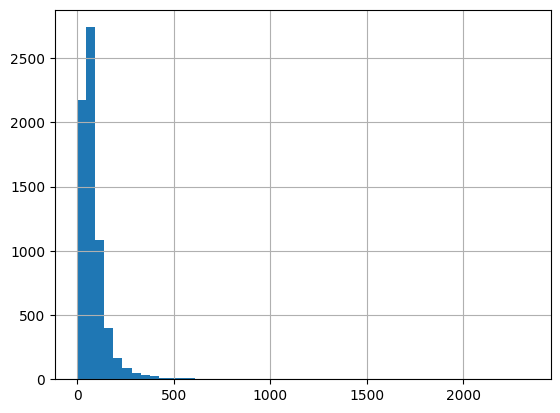

In [18]:
# histogram for column "Superficie somministrazione"
DATASET["Superficie somministrazione"].hist(bins=50)

In [19]:
# correlation evaluation between numeric columns using pearson correlation coefficient
DATASET.select_dtypes(['int64', 'float64']).corr(method='pearson')

,Codice via,ZD,Superficie somministrazione
Codice via,1.000000,0.426288,-0.054545
ZD,0.426288,1.000000,-0.017177
Superficie somministrazione,-0.054545,-0.017177,1.000000


In [20]:
# correlation evaluation between numeric columns using kendall correlation coefficient
DATASET.select_dtypes(['int64', 'float64']).corr(method='kendall')


,Codice via,ZD,Superficie somministrazione
Codice via,1.000000,0.422975,-0.040058
ZD,0.422975,1.000000,-0.019950
Superficie somministrazione,-0.040058,-0.019950,1.000000


In [21]:
# correlation evaluation between numeric columns using spearman correlation coefficient
corr = DATASET.select_dtypes(['int64', 'float64']).corr(method='spearman')

<Axes: >

<Axes: >

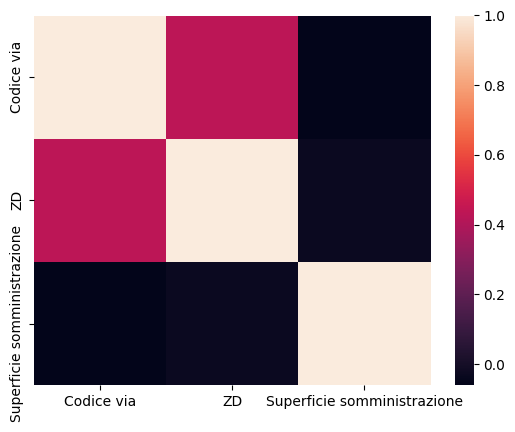

In [22]:
# correlation evaluation through heatmap
sns.heatmap(corr)

##### **2.1.6. General Profiling**

In [23]:
# generate a comprehensive profiling report of the dataset
profile = ProfileReport(DATASET, title="Data Information Quality Report")
profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 13/13 [00:00<00:00, 85.39it/s]


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 13/13 [00:00<00:00, 85.39it/s]


...

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 13/13 [00:00<00:00, 85.39it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

## **3. Data Transformation**
---

#### **3.1. Tipo via**

In [24]:
# check that the address type defined in "Tipo via" is contained also in "Ubicazione"
counter = 0

for index, row in DATASET.iterrows():
    tipo_via = row['Tipo via']
    ubicazione = row['Ubicazione']
    
    if pd.notnull(tipo_via) and pd.notnull(ubicazione):
        if tipo_via not in ubicazione:
            print(f"Mismatch at index {index}: Tipo via '{tipo_via}' not in Ubicazione '{ubicazione}'")
            counter += 1

print(f"\nTotal mismatches: {counter}")

Mismatch at index 10: Tipo via 'VIA' not in Ubicazione 'codvia 6511 parco villa scheibler; (z.d. 7)'
Mismatch at index 11: Tipo via 'VLE' not in Ubicazione 'codvia 9401 ff central; (z.d. 2)'
Mismatch at index 46: Tipo via 'VIA' not in Ubicazione 'CSO GARIBALDI GIUSEPPE num.072/3 /3 con esposiz. in via palermo; (z.d. 1)'
Mismatch at index 140: Tipo via 'VLE' not in Ubicazione 'PZA LUIGI DI SAVOIA num.001/6 ; (z.d. 2)'
Mismatch at index 141: Tipo via 'VIA' not in Ubicazione 'PZA LUIGI DI SAVOIA num.001/9 ing. anche da int.staz. centr.; (z.d. 2)'
Mismatch at index 305: Tipo via 'VLE' not in Ubicazione 'VIA CAMBIASI POMPEO num.014/3 ; (z.d. 3)'
Mismatch at index 467: Tipo via 'VLE' not in Ubicazione 'VIA DELLA MOSCOVA num.046/9 con ing. anche da c.so garib..; (z.d. 1)'
Mismatch at index 579: Tipo via 'ALZ' not in Ubicazione 'VIA GIAMBELLINO num.131/5 /5; (z.d. 6)'
Mismatch at index 655: Tipo via 'VLE' not in Ubicazione 'VIA LOMELLINA num.005/7 /7; (z.d. 4)'
Mismatch at index 1078: Tipo via

In [25]:
# drop rows where "Tipo via" is not contained in "Ubicazione"
indices_to_drop = []

for index, row in DATASET.iterrows():
    tipo_via = row['Tipo via']
    ubicazione = row['Ubicazione']
    
    if pd.notnull(tipo_via) and pd.notnull(ubicazione):
        if tipo_via not in ubicazione:
            indices_to_drop.append(index)

DATASET = DATASET.drop(indices_to_drop).reset_index(drop=True)

print(f"Mismatched rows dropped: {len(indices_to_drop)}")

Mismatched rows dropped: 55


In [26]:
# retrieve all unique categories from "Tipo via" column, with their count
unique_categories = DATASET["Tipo via"].unique()
category_counts = {}

for category in unique_categories:
    count = DATASET[DATASET["Tipo via"] == category].shape[0]
    category_counts[category] = count

for category, count in category_counts.items():
    print(f"'{category}': {count}")

'ALZ': 38
'BST': 7
'CSO': 359
'GLL': 21
'LGO': 43
'PLE': 126
'PTA': 8
'PZA': 323
'RIP': 33
'VIA': 5065
'VLE': 812
'VIE': 2
'FOR': 6
'VLO': 4
'PAS': 1
'LARGO': 1


In [27]:
# fix wrong categories in "Tipo via" column
corrections = {
    "VIE": "VIA",
    "LARGO": "LGO"
}

#### **3.2. Descrizione via**

In [28]:
# check that address name defined in "Descrizione via" is contained also in "Ubicazione"
counter = 0

for index, row in DATASET.iterrows():
    tipo_via = row['Descrizione via']
    ubicazione = row['Ubicazione']

    if pd.notnull(tipo_via) and pd.notnull(ubicazione):
        if tipo_via not in ubicazione:
            print(f"Mismatch at index {index}: Tipo via '{tipo_via}' not in Ubicazione '{ubicazione}'")
            counter += 1

print(f"\nTotal mismatches: {counter}")

Mismatch at index 43: Tipo via 'ITALIA' not in Ubicazione 'CSO GARIBALDI GIUSEPPE num.051/a /a; (z.d. 1)'
Mismatch at index 48: Tipo via 'DI PORTA ROMANA' not in Ubicazione 'CSO ITALIA num.022/a a; (z.d. 1)'
Mismatch at index 356: Tipo via 'PERINI CARLO' not in Ubicazione 'VIA CENISIO num.010/b /b; (z.d. 8)'
Mismatch at index 367: Tipo via 'SAND GEORGE' not in Ubicazione 'VIA CHIANCIANO num.010/2 /2; (z.d. 9)'
Mismatch at index 512: Tipo via 'PRINCIPE EUGENIO' not in Ubicazione 'VIA FARINI CARLO num.003 ; (z.d. 8)'
Mismatch at index 621: Tipo via 'BRIOSCHI FRANCESCO' not in Ubicazione 'VIA LAMPEDUSA num.011/a ; (z.d. 5)'
Mismatch at index 633: Tipo via 'MURAT GIOACCHINO' not in Ubicazione 'VIA LIVIGNO num.006/b /b; (z.d. 9)'
Mismatch at index 693: Tipo via 'MOROSINI EMILIO' not in Ubicazione 'VIA MECENATE num.076/24 ; (z.d. 4)'
Mismatch at index 694: Tipo via 'TERTULLIANO' not in Ubicazione 'VIA MECENATE num.078/a /a; (z.d. 4)'
Mismatch at index 740: Tipo via 'MECENATE' not in Ubicazio

In [29]:
# drop rows where "Descrizione via" is not contained in "Ubicazione"
indices_to_drop = []

for index, row in DATASET.iterrows():
    tipo_via = row['Descrizione via']
    ubicazione = row['Ubicazione']
    
    if pd.notnull(tipo_via) and pd.notnull(ubicazione):
        if tipo_via not in ubicazione:
            indices_to_drop.append(index)

DATASET = DATASET.drop(indices_to_drop).reset_index(drop=True)

print(f"Mismatched rows dropped: {len(indices_to_drop)}")

Mismatched rows dropped: 52


#### **3.3. Civico**

In [30]:
# check that street number defined in "Civico" is contained also in "Ubicazione"
counter = 0

for index, row in DATASET.iterrows():
    civico = row['Civico']
    ubicazione = row['Ubicazione']

    if pd.notnull(civico) and pd.notnull(ubicazione):
        if civico not in ubicazione:
            print(f"Mismatch at index {index}: Civico '{civico}' not in Ubicazione '{ubicazione}'")
            counter += 1

print(f"\nTotal mismatches: {counter}")

Mismatch at index 2432: Civico '61' not in Ubicazione 'VLE MONZA num.043/c /c; isolato:346; accesso: accesso esterno; (z.d. 2)'
Mismatch at index 5054: Civico '128' not in Ubicazione 'VIA RIPAMONTI GIUSEPPE num.150/152 e civico 152; isolato:102; accesso: accesso esterno; (z.d. 5)'
Mismatch at index 5475: Civico '71' not in Ubicazione 'VIA FARINI CARLO num.078/80 /80; accesso: accesso esterno; (z.d. 9)'
Mismatch at index 5482: Civico '61' not in Ubicazione 'VLE MONZA num.090/92 /92; isolato:295; accesso: accesso esterno; (z.d. 2)'

Total mismatches: 4


In [31]:
# drop rows where "Civico" is not contained in "Ubicazione"
indices_to_drop = []

for index, row in DATASET.iterrows():
    civico = row['Civico']
    ubicazione = row['Ubicazione']
    
    if pd.notnull(civico) and pd.notnull(ubicazione):
        if civico not in ubicazione:
            indices_to_drop.append(index)

DATASET = DATASET.drop(indices_to_drop).reset_index(drop=True)

print(f"Mismatched rows dropped: {len(indices_to_drop)}")

Mismatched rows dropped: 4


#### **3.4. ZD**

In [32]:
# check that zone number defined in "ZD" is contained also in "Ubicazione"
counter = 0

for index, row in DATASET.iterrows():
    zd = row['ZD']
    ubicazione = row['Ubicazione']

    if pd.notnull(zd) and pd.notnull(ubicazione):
        match = re.search(r'z\.d\.\s*(\d+)', str(ubicazione).lower())

        if match:
            zd_from_ubicazione = match.group(1)

            if str(zd) != zd_from_ubicazione:
                print(f"Mismatch at index {index}: ZD '{zd}' not in Ubicazione ({ubicazione})")
                counter += 1

print(f"\nTotal mismatches: {counter}")

Mismatch at index 101: ZD '4' not in Ubicazione (PZA BONOMELLI GEREMIA N. 4 (z.d. 5))
Mismatch at index 238: ZD '2' not in Ubicazione (VIA BENGASI N. 7 (z.d. 1))
Mismatch at index 576: ZD '3' not in Ubicazione (VIA GOLDONI CARLO num.031/33 (int. hotel town house 31); (z.d. 6))
Mismatch at index 577: ZD '3' not in Ubicazione (VIA GOLDONI CARLO num.031/33 ; (z.d. 6))
Mismatch at index 592: ZD '4' not in Ubicazione (VIA GUICCIARDINI FRANCESCO N. 5 (z.d. 9))
Mismatch at index 1066: ZD '8' not in Ubicazione (VIA TRAIANO MARCO ULPIO N. 11 (z.d. 9))
Mismatch at index 1321: ZD '8' not in Ubicazione (VIA TRAIANO MARCO ULPIO N. 79 angolo via peverelli - edif. 4;ingresso via 7560 num.000; accesso: accesso esterno; (z.d. 9))
Mismatch at index 1595: ZD '5' not in Ubicazione (VIA BORROMINI FRANCESCO N. 13 ; isolato:163; accesso: accesso esterno; (z.d. 2))
Mismatch at index 1613: ZD '3' not in Ubicazione (VIA BUSCHI AVERARDO N. 20 ; isolato:086; accesso: accesso esterno; (z.d. 6))
Mismatch at index 1

In [33]:
# drop rows where "ZD" is not contained in "Ubicazione"
indices_to_drop = []

for index, row in DATASET.iterrows():
    zd = row['ZD']
    ubicazione = row['Ubicazione']

    if pd.notnull(zd) and pd.notnull(ubicazione):
        match = re.search(r'z\.d\.\s*(\d+)', str(ubicazione).lower())

        if match:
            zd_from_ubicazione = match.group(1)

            if str(zd) != zd_from_ubicazione:
                indices_to_drop.append(index)   
                
DATASET = DATASET.drop(indices_to_drop).reset_index(drop=True)

print(f"Mismatched rows dropped: {len(indices_to_drop)}")

Mismatched rows dropped: 29


#### **3.5. Ubicazione**

In [34]:
# check in which ways street numbe is defined in "Ubicazione"
occurences = []

for index, row in DATASET.iterrows():
    ubicazione = row['Ubicazione']

    match = re.search(r'(\b\w+\.?)\s*(\d+)', str(ubicazione))

    if match and match.group(1) not in occurences:
        occurences.append(match.group(1))

occurences

['N.', 'num.']

In [35]:
# change all the "num." to "N." in the "Ubicazione" column
counter = 0

for index, row in DATASET.iterrows():
    ubicazione = row['Ubicazione']

    if pd.notnull(ubicazione):
        updated_ubicazione, n = re.subn(r'\bnum\.?\s*', 'N. ', str(ubicazione), flags=re.IGNORECASE)

        if n > 0:
            DATASET.at[index, 'Ubicazione'] = updated_ubicazione
            counter += 1

print(f"Total rows updated: {counter}")

Total rows updated: 162


#### **3.6. Tipo di esercizio storico pe**

In [36]:
# enumerate all the unique values in the "Tipo esercizio storico pe" column, each one with its count
unique_values = DATASET["Tipo esercizio storico pe"].unique()
value_counts = DATASET["Tipo esercizio storico pe"].value_counts()

for value, count in value_counts.items():
    display_value = 'NaN' if pd.isna(value) else value
    print(f"'{display_value}': {count}")

'bar caffè': 3217
'ristorante': 784
'trattoria': 548
'pizzeria': 344
'tavola calda': 101
'spaccio bevande analcoliche': 81
'ristorante, trattoria, osteria': 62
'bar gastronomici e simili': 48
'gelateria': 46
'osteria': 38
'tavola fredda': 34
'bar-caffe' e simili': 29
'genere merceol.autorizz.sanit.': 27
'birreria': 21
'pizzerie e simili': 15
'bar pasticc.gelat.crem.creper.': 11
'cibi cotti': 10
'tav.calde,self service,fast f.': 9
'cibi cotti preconfezionati': 7
'prodotti di gastronomia': 7
'wine,birr.,pub enot.,caff.,the': 4
'sale da ballo, locali notturni': 3
'mensa': 1


In [37]:
# substitute those values with defined ones

substitutions = {
    'bar caffè': 'bar',
    "bar-caffe' e simili": 'bar',
    'bar gastronomici e simili': 'bar',
    'bar pasticc.gelat.crem.creper.': 'bar',
    'spaccio bevande analcoliche': 'bar',

    'sale da ballo, locali notturni': 'locali notturni',

    'ristorante, trattoria, osteria': 'ristorante',

    'pizzerie e simili': 'pizzeria',

    'tavola calda': 'gastronomia',
    'tavola fredda': 'gastronomia',
    'tav.calde,self service,fast f.': 'gastronomia',
    'cibi cotti': 'gastronomia',
    'cibi cotti preconfezionati': 'gastronomia',
    'prodotti di gastronomia': 'gastronomia',

    'birreria': 'pub',
    'wine,birr.,pub enot.,caff.,the': 'pub',

    'genere merceol.autorizz.sanit.': 'genere merceologico autorizzato sanitariamente'
}

# apply substitutions to the dataset
for index, row in DATASET.iterrows():
    tipo_esercizio = row['Tipo esercizio storico pe']

    if pd.notnull(tipo_esercizio):
        tipo_esercizio_lower = tipo_esercizio.lower()

        if tipo_esercizio_lower in substitutions:
            DATASET.at[index, 'Tipo esercizio storico pe'] = substitutions[tipo_esercizio_lower]

# enumerate all the new unique values in the "Tipo esercizio storico pe" column, each one with its count
unique_values = DATASET["Tipo esercizio storico pe"].unique()
value_counts = DATASET["Tipo esercizio storico pe"].value_counts()

for value, count in value_counts.items():
    display_value = 'NaN' if pd.isna(value) else value
    print(f"'{display_value}': {count}")     

'bar': 3386
'ristorante': 846
'trattoria': 548
'pizzeria': 359
'gastronomia': 168
'gelateria': 46
'osteria': 38
'genere merceologico autorizzato sanitariamente': 27
'pub': 25
'locali notturni': 3
'mensa': 1


#### **3.7. Settore storico pe**

In [38]:
# enumerate all the unique values in the "Settore storico pe" column, each one with its count
unique_values = DATASET["Settore storico pe"].unique()
value_counts = DATASET["Settore storico pe"].value_counts()

for value, count in value_counts.items():
    display_value = 'NaN' if pd.isna(value) else value
    print(f"'{display_value}': {count}")


'Genere Merceol.Autorizz.Sanit.': 209
'Ristorante, trattoria, osteria': 172
'Bar gastronomici e simili': 157
'BAR CAFFÈ E SIMILI': 82
'BAR CAFFÈ E SIMILI;Bar gastronomici e simili': 55
'Bar gastronomici e simili;BAR CAFFÈ E SIMILI': 47
'Bar pasticc.gelat.crem.creper.': 39
'Ristorante, trattoria, osteria;BAR CAFFÈ E SIMILI': 33
'Ristorante, trattoria, osteria;Genere Merceol.Autorizz.Sanit.;Ristorante': 32
'Genere Merceol.Autorizz.Sanit.;Ristorante;Ristorante, trattoria, osteria': 29
'Pizzerie e simili': 29
'Wine,birr.,pub enot.,caff.,the': 25
'Ristorante;Ristorante, trattoria, osteria;Genere Merceol.Autorizz.Sanit.': 24
'BAR CAFFÈ E SIMILI;Ristorante, trattoria, osteria': 23
'Pizzerie e simili;Ristorante, trattoria, osteria': 22
'Genere Merceol.Autorizz.Sanit.;Trattoria;Ristorante, trattoria, osteria': 22
'BAR CAFFÈ': 22
'Genere Merceol.Autorizz.Sanit.;Ristorante, trattoria, osteria;Ristorante': 20
'Ristorante;Genere Merceol.Autorizz.Sanit.;Ristorante, trattoria, osteria': 19
'Ristorant

In [39]:
# make all the entries in "Settore storico pe" column lowercase
for index, row in DATASET.iterrows():
    settore = row['Settore storico pe']

    if pd.notnull(settore):
        DATASET.at[index, 'Settore storico pe'] = settore.lower()

In [40]:
# extract all the unique values from "Settore storico pe" column with count, splitting by comma and semicolon each entry
unique_values = set()
value_counts = {}

for index, row in DATASET.iterrows():
    settore = row['Settore storico pe']

    if pd.notnull(settore):
        entries = re.split(r'[;,]\s*', settore)

        for entry in entries:
            entry = entry.strip()

            if entry:
                unique_values.add(entry)

                if entry in value_counts:
                    value_counts[entry] += 1
                else:
                    value_counts[entry] = 1


for value in sorted(unique_values):
    count = value_counts.get(value, 0)
    print(f"'{value}': {count}")

'altre apparecchiature elettr.': 1
'bar': 2
'bar caffe' gelateria': 1
'bar caffè': 4531
'bar caffè e simili': 2802
'bar gastronomici e simili': 2456
'bar gelateria': 1
'bar pasticc.gelat.crem.creper.': 422
'bar pasticceria': 1
'bigliardino elettrico': 16
'biliardo': 37
'birr.': 308
'birreria': 2
'bocce': 31
'caff.': 308
'caffè bar - somministrazione': 1
'calcio da tavolo': 7
'carte': 73
'cibi cotti': 75
'cibi cotti preconfezionati': 1046
'cucina tipica lombarda': 55
'disco-piano-americ.bar serali': 102
'discoteche': 7
'elettr.automatici meccaniche': 118
'fast': 1
'fast f.': 360
'gelateria': 102
'genere merceol.autorizz.sanit.': 4724
'giochi di societa'': 3
'giochi leciti': 5
'giochi legge 38': 1
'giochi legge 388/2000': 467
'gioco video': 32
'lett. giochi leciti + societa'': 42
'licenza giochi leciti/elettr..': 32
'locali notturni': 5
'osteria': 2203
'pizzeria': 935
'pizzerie e simili': 827
'prodotti di gastronomia': 739
'pub enot.': 308
'ristorant': 1
'ristorante': 3350
'ristorante co

In [41]:
# merge similar values in "Settore storico pe" column
substitutions = {
    "bar": "Bar",
    "bar caffè": "Bar",
    "bar caffe": "Bar",
    "bar caffè e simili": "Bar",
    "bar gastronomici e simili": "Bar",
    "bar gelateria": "Bar",
    "bar pasticceria": "Bar",
    "bar pasticc.gelat.crem.creper.": "Bar",
    "caff.": "Bar",
    "bar caffe' gelateria": "Bar",
    "caffè bar - somministrazione": "Bar",
    "spaccio bevande analcoliche": "Bar",

    "ristorante": "Ristorante",
    "ristorant": "Ristorante",
    "ristorante con somministrazione": "Ristorante",
    "ristorazione con somministrazione": "Ristorante",
    "somministrazione": "Ristorante",
    "somministrazione alimenti e bevande": "Ristorante",
    "somministrazione di alimenti e bevande": "Ristorante",
    "cucina tipica lombarda": "Ristorante",

    "pizzeria": "Pizzeria",
    "pizzerie e simili": "Pizzeria",

    "trattoria": "Trattoria",

    "osteria": "Osteria",

    "gelateria": "Gelateria",

    "fast": "Fast food",
    "fast f.": "Fast food",

    "self service": "Self service",

    "tav.calde": "Tavola calda",
    "tavola calda": "Tavola calda",

    "tavola fredda": "Tavola fredda",

    "birr.": "Birreria",
    "birreria": "Birreria",
    
    "pub enot.": "Enoteca",
    "wine": "Enoteca",

    "the": "The",

    "cibi cotti": "Gastronomia",
    "cibi cotti preconfezionati": "Gastronomia",
    "prodotti di gastronomia": "Gastronomia",

    "genere merceol.autorizz.sanit.": "Genere merceologico autorizzato sanitariamente",
    
    "biliardo": "Intrattenimento",
    "bocce": "Intrattenimento",
    "bigliardino elettrico": "Intrattenimento",
    "calcio da tavolo": "Intrattenimento",
    "tennis da tavolo": "Intrattenimento",
    "gioco video": "Intrattenimento",
    "giochi di societa'": "Intrattenimento",
    "sale da gioco": "Intrattenimento",
    "carte": "Intrattenimento",

    "giochi leciti": "Gioco d'azzardo",
    "giochi legge 38": "Gioco d'azzardo",
    "giochi legge 388/2000": "Gioco d'azzardo",
    "licenza giochi leciti/elettr..": "Gioco d'azzardo",
    "lett. giochi leciti + societa'": "Gioco d'azzardo",
    "elettr.automatici meccaniche": "Gioco d'azzardo",

    "discoteche": "Locali notturni",
    "sale ballo notturni": "Locali notturni",
    "sale da ballo": "Locali notturni",
    "locali notturni": "Locali notturni",
    "disco-piano-americ.bar serali": "Locali notturni",

    "altre apparecchiature elettr.": "Altro",
    "seconda bottiglia": "Altro",
    "terza bottiglia": "Altro",
}

# apply substitutions to the dataset
for index, row in DATASET.iterrows():
    settore = row['Settore storico pe']

    if pd.notnull(settore):
        entries = re.split(r'[;,]\s*', settore)
        new_entries = []

        for entry in entries:
            entry = entry.strip()

            if entry in substitutions:
                new_entries.append(substitutions[entry])
            else:
                new_entries.append(entry)

        DATASET.at[index, 'Settore storico pe'] = ', '.join(new_entries)   


In [42]:
# generate a new column for each category in "Settore storico pe" with binary values
categories = set()

for index, row in DATASET.iterrows():
    settore = row['Settore storico pe']

    if pd.notnull(settore):
        entries = re.split(r'[;,]\s*', settore)

        for entry in entries:
            entry = entry.strip()

            if entry:
                categories.add(entry)

for category in categories:
    DATASET[category] = 0

for index, row in DATASET.iterrows():
    settore = row['Settore storico pe']

    if pd.notnull(settore):
        entries = re.split(r'[;,]\s*', settore)

        for entry in entries:
            entry = entry.strip()

            if entry in categories:
                DATASET.at[index, entry] = 1

In [43]:
# for each category, count how many entries have value 1
category_counts = {}

for category in categories:
    count = DATASET[category].sum()
    category_counts[category] = count

for category, count in category_counts.items():
    print(f"'{category}': {(count / DATASET.shape[0] * 100):.2f}%")

'Fast food': 5.29%
'Locali notturni': 1.61%
'Altro': 1.05%
'Tavola fredda': 33.25%
'Pizzeria': 17.21%
'Trattoria': 34.83%
'Intrattenimento': 1.37%
'Bar': 80.10%
'Tavola calda': 10.62%
'Gastronomia': 27.48%
'The': 4.54%
'Genere merceologico autorizzato sanitariamente': 69.69%
'Enoteca': 4.54%
'Osteria': 31.83%
'Self service': 5.29%
'Gioco d'azzardo': 9.03%
'Birreria': 4.55%
'Ristorante': 36.28%
'Gelateria': 1.51%


In [44]:
# drop "Settore storico pe" column, since its information has been splitted into multiple columns
DATASET = DATASET.drop(columns=['Settore storico pe'])

#### **3.8. Insegna**

In [45]:
# drop "Insegna" column, as it contains mostly missing values and does not provide useful information
DATASET = DATASET.drop(columns=['Insegna'])

## **4. Association Rules**
---

In [46]:
# !git clone https://github.com/camillasancricca/DATADIQ.git

# from DATADIQ import scripts_for_E5 as scripts

In [47]:
categorical_cols = [
    'Tipo esercizio storico pe', 'ZD', 'Forma commercio', 'Forma commercio prev', 'Forma vendita'
]

boolean_cols = [
    'Genere merceologico autorizzato sanitariamente', 'Trattoria', 'Pizzeria', 'Birreria', 'Osteria', 'Ristorante',
    'Tavola calda', 'The', 'Bar', 'Intrattenimento', "Gioco d'azzardo",
    'Gelateria', 'Fast food', 'Self service', 'Tavola fredda',
    'Gastronomia', 'Altro', 'Locali notturni', 'Enoteca'
]

DS = DATASET.copy()

# put all items of each row into a list
transactions = []

for _, row in DS.iterrows():
    transaction = []

    # categorical features
    for col in categorical_cols:
        val = row[col]
        if pd.notnull(val):
            transaction.append(f"{col}={val}")

    # boolean features (only if 1)
    for col in boolean_cols:
        if row[col] == 1:
            transaction.append(col)

    transactions.append(transaction)

In [48]:
# apply fpgrowth algorithm to find association rules
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)

df = pd.DataFrame(te_ary, columns=te.columns_)
freq = fpgrowth(df, min_support=0.3, use_colnames=True)

rules = association_rules(freq, metric="confidence", min_threshold=0.85)
rules = rules.sort_values("confidence", ascending=False)
rules = rules[rules['consequents'].apply(lambda x: any(item.startswith('Forma commercio prev=') or item.startswith('Forma commercio=') for item in x))]
rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
22,"(Forma commercio=solo somministrazione, Bar)",(Forma commercio prev=somministrazione),0.568598,0.780899,0.567120,0.997400,1.277246,1.0,0.123102,84.266292,0.503163,0.724868,0.988133,0.861820
20,"(Forma commercio=solo somministrazione, Bar, G...",(Forma commercio prev=somministrazione),0.468214,0.780899,0.466884,0.997158,1.276936,1.0,0.101256,77.099251,0.407825,0.596863,0.987030,0.797519
16,(Forma commercio=solo somministrazione),(Forma commercio prev=somministrazione),0.690420,0.780899,0.688350,0.997002,1.276737,1.0,0.149202,73.085875,0.700152,0.879154,0.986317,0.939243
18,"(Forma commercio=solo somministrazione, Genere...",(Forma commercio prev=somministrazione),0.557954,0.780899,0.556180,0.996820,1.276504,1.0,0.120474,68.907303,0.490017,0.710616,0.985488,0.854525
29,"(Tipo esercizio storico pe=bar, Forma commerci...",(Forma commercio prev=somministrazione),0.408782,0.780899,0.407451,0.996745,1.276407,1.0,0.088234,67.312734,0.366279,0.520885,0.985144,0.759259
31,"(Tipo esercizio storico pe=bar, Forma commerci...",(Forma commercio prev=somministrazione),0.405825,0.780899,0.404494,0.996721,1.276377,1.0,0.087586,66.825843,0.364425,0.517105,0.985036,0.757353
43,"(Tipo esercizio storico pe=bar, Forma commerci...",(Forma commercio prev=somministrazione),0.340627,0.780899,0.339444,0.996528,1.276129,1.0,0.073449,63.101124,0.328160,0.434026,0.984152,0.715606
48,"(Tipo esercizio storico pe=bar, Forma commerci...",(Forma commercio prev=somministrazione),0.339740,0.780899,0.338557,0.996519,1.276117,1.0,0.073255,62.936798,0.327709,0.432892,0.984111,0.715033
51,"(Tipo esercizio storico pe=bar, Forma commerci...","(Forma commercio prev=somministrazione, Bar)",0.340627,0.653312,0.338557,0.993924,1.521362,1.0,0.116022,57.054997,0.519727,0.516580,0.982473,0.756070
33,"(Tipo esercizio storico pe=bar, Forma commerci...","(Forma commercio prev=somministrazione, Bar)",0.408782,0.653312,0.404494,0.989512,1.514609,1.0,0.137432,33.054941,0.574684,0.615108,0.969747,0.804328


In [49]:
# from the generated rules we select:

# (Forma commercio = solo somministrazione) --> (Forma commercio prev = somministrazione)
# (Forma commercio prev = somministrazione) --> (Forma commercio = solo somministrazione)
# (Tipo esercizio storico pe = bar) --> (Forma commercio prev = somministrazione)
# (Forma vendita = misto) --> (Forma commercio prev = somministrazione)

## **5. Missing Values**
---

#### **5.1. Civico**

In [50]:
# count missing values in "Civico" column
missing_civico = DATASET['Civico'].isnull().sum()
missing_civico

np.int64(154)

In [51]:
# fill the missing values in "Civico" column with number found after "N. " in "Ubicazione" column
count = 0

for index, row in DATASET.iterrows():
    civico = row['Civico']
    ubicazione = row['Ubicazione']

    if pd.isnull(civico) and pd.notnull(ubicazione):
        match = re.search(r'\bN\.?\s*(\d+)(?=\s*/|\s|$)', str(ubicazione), flags=re.IGNORECASE)

        if match:
            extracted_civico = match.group(1).lstrip('0')
            DATASET.at[index, 'Civico'] = extracted_civico
            count += 1

print(f"Total 'Civico' values filled: {count}")


Total 'Civico' values filled: 154


In [52]:
# drop "Ubicazione" column, since all its information are redundant with other columns
DATASET = DATASET.drop(columns=['Ubicazione'])

#### **5.2. Superficie somministrazione**

In [53]:
# count missing values in "Superficie somministrazione" column
missing_superficie = DATASET['Superficie somministrazione'].isnull().sum()
missing_superficie

np.int64(77)

In [54]:
# compute the mean of "Superficie somministrazione" column
mean_superficie = DATASET['Superficie somministrazione'].mean()

# fill missing values in "Superficie somministrazione" column with the integer mean value
DATASET['Superficie somministrazione'] = DATASET['Superficie somministrazione'].fillna(int(mean_superficie))

print(f"Filled missing 'Superficie somministrazione' values with mean: {int(mean_superficie)}")

Filled missing 'Superficie somministrazione' values with mean: 85


#### **5.3. Forma commercio**

In [55]:
# fill missing values in "Forma commercio" column starting from the association rule: 

# (Forma commercio prev = somministrazione) --> (Forma commercio = solo somministrazione)

count = 0

for index, row in DATASET.iterrows():
    forma_commercio = row['Forma commercio']
    forma_commercio_prev = row['Forma commercio prev']

    if pd.isnull(forma_commercio) and pd.notnull(forma_commercio_prev):
        if forma_commercio_prev == 'somministrazione':
            DATASET.at[index, 'Forma commercio'] = 'solo somministrazione'
            count += 1

print(f"Total 'Forma commercio' values filled: {count}")

Total 'Forma commercio' values filled: 173


#### **5.4. Forma commercio prev**

In [56]:
# fill missing values in "Forma commercio" column starting from the association rule: 

# (Forma commercio = solo somministrazione) --> (Forma commercio prev = somministrazione)
# (Tipo esercizio storico pe = bar) --> (Forma commercio prev = somministrazione)
# (Forma vendita = misto) --> (Forma commercio prev = somministrazione)

count = 0

for index, row in DATASET.iterrows():
    forma_commercio = row['Forma commercio']
    forma_commercio_prev = row['Forma commercio prev']
    tipo_esercizio = row['Tipo esercizio storico pe']
    forma_vendita = row['Forma vendita']

    if pd.isnull(forma_commercio):
        if pd.notnull(forma_commercio_prev) and forma_commercio == 'solo somministrazione':
            DATASET.at[index, 'Forma commercio prev'] = 'somministrazione'
            count += 1
        elif pd.notnull(tipo_esercizio) and tipo_esercizio == 'bar':
            DATASET.at[index, 'Forma commercio prev'] = 'somministrazione'
            count += 1
        elif pd.notnull(forma_vendita) and forma_vendita == 'misto':
            DATASET.at[index, 'Forma commercio prev'] = 'somministrazione'
            count += 1

print(f"Total 'Forma commercio prev' values filled: {count}")

Total 'Forma commercio prev' values filled: 40


#### **5.5. Last missing values**

In [57]:
# used linear models to impute missing values in "Tipo esercizio storico pe", "Forma vendita", "Forma commercio", "Forma commercio prev" columns
# in particular, were used the boolean columns extracted from "Settore storico pe" as parameters

# encoding function
def encoding_categorical_variables(df):
    cat_cols = df.select_dtypes(include=['object', 'bool']).columns
    num_cols = df.select_dtypes(include='number').columns
    
    # one-hot encode categorical
    encoder = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')
    cat_encoded = pd.DataFrame(encoder.fit_transform(df[cat_cols]), columns=encoder.get_feature_names_out(cat_cols))
    
    # concatenate with numerical
    encoded_df = pd.concat([cat_encoded, df[num_cols].reset_index(drop=True)], axis=1)
    return encoded_df

missing_columns = ['Tipo esercizio storico pe', 'Forma vendita', 'Forma commercio', 'Forma commercio prev']

IMP_DATA = pd.DataFrame(columns = ["IMP" + name for name in missing_columns], index=DATASET.index)
DATA_filled = DATASET.copy()

CATEGORICAL_COLS = DATA_filled.select_dtypes(include=['object', 'bool']).columns.to_list()
NUM_COLS = DATA_filled.select_dtypes(include='number').columns.to_list()

# define new_sectors_columns as the boolean columns from settore
new_sectors_columns = [
    'Genere merceologico autorizzato sanitariamente', 'Trattoria', 'Pizzeria', 'Birreria', 'Osteria', 'Ristorante',
    'Tavola calda', 'The', 'Bar', 'Intrattenimento', "Gioco d'azzardo",
    'Gelateria', 'Fast food', 'Self service', 'Tavola fredda',
    'Gastronomia', 'Altro', 'Locali notturni', 'Enoteca'
]

for feature in missing_columns:
    parameters = list(set(
        # this should help deducing the first features, where the location is not really relevant
        new_sectors_columns + [ 'Tipo esercizio storico pe' ]
        # remove the feature itself
        ) - { feature })

    # create a Logistic Regression model to estimate the missing data
    model = linear_model.LogisticRegression(solver='lbfgs', max_iter=1000)

    # encode categorical data
    param_data = DATASET[parameters]
    X = encoding_categorical_variables(param_data)

    non_null = DATASET[feature].notnull()
    is_null = DATASET[feature].isnull()
    model.fit(
        X = X.iloc[non_null.values],
        y = DATASET[feature].loc[non_null])
    model_predicted = model.predict(X.iloc[is_null.values])

    # fill the missing values 
    DATASET.loc[is_null, feature] = model_predicted

    print('"' + feature + '" successfully imputed')

"Tipo esercizio storico pe" successfully imputed
"Forma vendita" successfully imputed
"Forma commercio" successfully imputed
"Forma commercio prev" successfully imputed


## **6. Outliers Detection**
---

#### **6.1. Superficie somministrazione**

In [58]:
# display extremes values for column "Superficie somministrazione"
min = DATASET["Superficie somministrazione"].min()
max = DATASET["Superficie somministrazione"].max()

print("MIN:", min)
print("MAX:", max)

MIN: 2.0
MAX: 2336.0


In [59]:
# this is the only column that could present outliers
# although, we stated that all the values are reasonable

## **7. Duplicates Detection**
---

In [60]:
# check for duplicates in the dataset
DUPLICATES = DATASET.duplicated()
DATASET[DUPLICATES]

,Tipo esercizio storico pe,Tipo via,Descrizione via,Civico,Codice via,ZD,Forma commercio,Forma commercio prev,Forma vendita,Superficie somministrazione,...,Gastronomia,The,Genere merceologico autorizzato sanitariamente,Enoteca,Osteria,Self service,Gioco d'azzardo,Birreria,Ristorante,Gelateria
368,bar,VIA,CHIESE,60,1627,9,solo somministrazione,somministrazione,misto,90.0,...,1,0,1,0,1,0,0,0,1,0
615,bar,VIA,LECCO,12,2110,3,solo somministrazione,somministrazione,al banco,85.0,...,0,0,0,0,0,0,0,0,0,0
913,ristorante,VIA,SALASCO,29,4051,5,solo somministrazione,somministrazione,misto,85.0,...,0,0,0,0,0,0,0,0,1,0
915,bar,VIA,SALASCO,29,4051,5,solo somministrazione,somministrazione,al banco,85.0,...,0,0,0,0,0,0,0,0,0,0
5757,ristorante,VIA,MANZONI ALESSANDRO,29,230,1,solo somministrazione,somministrazione,al tavolo,70.0,...,0,0,1,0,1,0,0,0,1,0


In [61]:
# drop duplicate rows
DATASET = DATASET.drop_duplicates().reset_index(drop=True)

print(f"Exact matching rows dropped: {DUPLICATES.sum()}")

Exact matching rows dropped: 5


In [62]:
# compute new "Ubicazione" column by concatenating "Tipo via", "Descrizione via", and "Civico" columns
DATASET['Ubicazione'] = DATASET['Tipo via'].str.strip() + ' ' + DATASET['Descrizione via'].str.strip() + ', ' + DATASET['Civico'].astype(str).str.strip()

In [63]:
# perform record linkage to find potential duplicate records
indexer = recordlinkage.index.SortedNeighbourhood(left_on='Ubicazione', right_on='Ubicazione', window=9)

candidate_links = indexer.index(DATASET)

compare = recordlinkage.Compare()

# exact compares
exact_columns = [
    'Tipo esercizio storico pe', 'Tipo via', 'ZD', 
    'Forma commercio', 'Civico', 'Codice via','Forma commercio prev',
    'Forma vendita', 'Superficie somministrazione', 'Gelateria',
    "Gioco d'azzardo", 'Gastronomia', 'Enoteca', 'Intrattenimento',
    'Locali notturni', 'Bar', 'Birreria', 'Tavola fredda', 'Osteria',
    'Fast food', 'Self service', 'Altro', 'Pizzeria', 'Tavola calda',
    'Trattoria', 'The', 'Genere merceologico autorizzato sanitariamente',
    'Ristorante'
]

for col in exact_columns:
    compare.exact(col, col, label=col)

# string compare
string_columns = [
    'Ubicazione', 'Descrizione via'
]

for col in string_columns:
    compare.string(col, col, method='jarowinkler', threshold=0.85, label=col)

# compute comparison features for candidate links
features = compare.compute(candidate_links, DATASET)

# filter matches with at least 29 matching features
matches = features[features.sum(axis=1) >= 29]
matches

,,Tipo esercizio storico pe,Tipo via,ZD,Forma commercio,Civico,Codice via,Forma commercio prev,Forma vendita,Superficie somministrazione,Gelateria,...,Self service,Altro,Pizzeria,Tavola calda,Trattoria,The,Genere merceologico autorizzato sanitariamente,Ristorante,Ubicazione,Descrizione via
3940,2768,1,1,1,1,0,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1.0,1.0
39,38,1,1,1,1,1,1,1,1,0,1,...,1,1,1,1,1,1,1,1,1.0,1.0
56,55,1,1,1,1,1,1,1,1,0,1,...,1,1,1,1,1,1,1,1,1.0,1.0
107,106,1,1,1,1,1,1,1,1,0,1,...,1,1,1,1,1,1,1,1,1.0,1.0
111,110,1,1,1,1,1,1,1,1,0,1,...,1,1,1,1,1,1,1,1,1.0,1.0
137,136,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1.0,1.0
156,155,1,1,1,1,1,1,1,1,0,1,...,1,1,1,1,1,1,1,1,1.0,1.0
337,336,1,1,1,1,1,1,1,1,0,1,...,1,1,1,1,1,1,1,1,1.0,1.0
370,369,1,1,1,1,1,1,1,1,0,1,...,1,1,1,1,1,1,1,1,1.0,1.0
452,451,1,1,1,1,1,1,1,1,0,1,...,1,1,1,1,1,1,1,1,1.0,1.0


In [64]:
# filter matches to avoid records with different street numbers
final_matches = []
for index, row in matches.iterrows():
    idx1, idx2 = index
    civico1 = DATASET.at[idx1, 'Civico']
    civico2 = DATASET.at[idx2, 'Civico']

    if civico1 == civico2:
        final_matches.append(index)

final_matches_df = pd.DataFrame(final_matches, columns=['Index1', 'Index2'])
final_matches_df

,Index1,Index2
0,39,38
1,56,55
2,107,106
3,111,110
4,137,136
5,156,155
6,337,336
7,370,369
8,452,451
9,501,500


In [65]:
# drop duplicate rows found by record linkage
indices_to_drop = set()
for idx1, idx2 in final_matches:
    indices_to_drop.add(idx2)   

DATASET = DATASET.drop(index=indices_to_drop).reset_index(drop=True)

In [66]:
# drop "Ubicazione" column, as it was only needed for record linkage
DATASET = DATASET.drop(columns=['Ubicazione'])

## **8. Cleaned Dataset**
---

In [67]:
# assess the cleanyness of the cleaned dataset
profile_cleaned = ProfileReport(DATASET, title="Cleaned Data Information Quality Report")
profile_cleaned

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 29/29 [00:00<00:00, 324.91it/s]


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 29/29 [00:00<00:00, 324.91it/s]


...

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 29/29 [00:00<00:00, 324.91it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [68]:
# save the cleaned dataset to a new CSV file
DATASET.to_csv('output.csv', sep=';', encoding='utf-16', index=False)

## **9. Data Analysis**
---

In [69]:
# save in different constants the dirty and cleaned datasets
DIRTY_DATASET = pd.read_csv('input.csv', sep=';', encoding='utf-16')
CLEANED_DATASET = pd.read_csv('output.csv', sep=';', encoding='utf-16')

In [91]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

# config
TARGET_COLUMN = 'Tipo esercizio storico pe'
TEST_SIZE = 0.3
N_NEIGHBORS = 7
MISSING_VALUE_PLACEHOLDER = 'NaN'

def cassification_performance(df):
    # prepare features and target
    features_df = df.loc[:, df.columns != TARGET_COLUMN]
    X = encoding_categorical_variables(features_df).values
    y = df[TARGET_COLUMN].values
    
    # split data: 70% training, 30% testing
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE)
    
    # normalize features to same scale
    scaler = StandardScaler()
    scaler.fit(X_train)
    X_train = scaler.transform(X_train)
    X_test = scaler.transform(X_test)
    
    # handle missing numeric values
    X_train = np.nan_to_num(X_train)
    X_test = np.nan_to_num(X_test)
    
    # handle missing labels
    y_train[pd.isna(y_train)] = MISSING_VALUE_PLACEHOLDER
    y_test[pd.isna(y_test)] = MISSING_VALUE_PLACEHOLDER
    
    # train the classifier
    classifier = KNeighborsClassifier(n_neighbors=N_NEIGHBORS)
    classifier.fit(X_train, y_train)
    
    # make predictions
    y_predict = classifier.predict(X_test)
    
    # show results
    print(classification_report(y_test, y_predict, zero_division=0))

In [94]:
# assess classification performance on dirty dataset
cassification_performance(DIRTY_DATASET)

                                precision    recall  f1-score   support

                           NaN       0.20      1.00      0.33       407
                     bar caff�       0.00      0.00      0.00       996
     bar gastronomici e simili       0.00      0.00      0.00        15
bar pasticc.gelat.crem.creper.       0.00      0.00      0.00         5
           bar-caffe' e simili       0.00      0.00      0.00        12
                      birreria       0.00      0.00      0.00         9
                    cibi cotti       0.00      0.00      0.00         2
    cibi cotti preconfezionati       0.00      0.00      0.00         2
                     gelateria       0.00      0.00      0.00        15
genere merceol.autorizz.sanit.       0.00      0.00      0.00         7
                       osteria       0.00      0.00      0.00         9
                      pizzeria       0.00      0.00      0.00        98
             pizzerie e simili       0.00      0.00      0.00  

In [95]:
# assess classification performance on the cleaned dataset
cassification_performance(CLEANED_DATASET)

                                                precision    recall  f1-score   support

                                           bar       0.64      0.98      0.78      1292
                                   gastronomia       0.00      0.00      0.00        51
                                     gelateria       0.00      0.00      0.00        14
genere merceologico autorizzato sanitariamente       0.00      0.00      0.00         7
                               locali notturni       0.00      0.00      0.00         2
                                       osteria       0.00      0.00      0.00        15
                                      pizzeria       0.00      0.00      0.00       110
                                           pub       0.00      0.00      0.00         6
                                    ristorante       0.23      0.03      0.05       350
                                     trattoria       0.10      0.01      0.02       172

                              